# *Meta-labeling shortlist*: evidencias de la corrida exploratoria definitiva

Lee los artefactos persistidos bajo `reports/validation/experiments/advanced_studies/meta_labeling_shortlist_*.json` (un archivo por celda) y el log `logs/meta_labeling_exp15_batch_best_per_family_disabled_fallback_20260504_131934.log`. **No entrena modelos.**

Salida en `reports/validation/experiments/meta_labeling_shortlist_evidence/` (tablas CSV/Markdown y figuras PNG).

**Complemento:** `05_modelado_predictivo/04_evidencia_robustez_fold_shortlist_meta_labeling.ipynb` (robustez fold-level: dispersión de `delta_sharpe`, heatmaps, trayectorias primario vs meta y Wilcoxon entre familias) exporta al mismo manifest `meta_labeling_shortlist_evidence/`.

## Corrida analizada

Este notebook analiza **una sola** corrida: `disabled_gate_best_per_family_with_fallback`.

- *Gate* de segunda ola **desactivado** (`meta_gate_mode=disabled`).
- *Shortlist* `best_per_family` con *fallback* confirmatorio -> exploratorio por familia.
- Última corrida cronológica del Exp1.5 (4 mayo 2026) y la **única** con panel completo 5×3 (15 celdas, 30 meta estudios `completed`).

## Preguntas que responde

- ¿Cuál es la **cobertura operativa** del panel 5×3 (`n_candidatos`, `n_completados`, `n_no_ejecutables`)?
- ¿Qué métricas agregadas (`media_delta_sharpe`, `media_meta_f1`, `media_ratio_cobertura`) consigue cada celda donde el *meta-labeling* se completa?

In [1]:
from __future__ import annotations

import sys
from pathlib import Path
from typing import Any, Iterable, Mapping

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

for _parent in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
    if (_parent / "src").is_dir() and (_parent / "evidence_utils").is_dir():
        _loaders_dir = _parent / "evidence_utils"
        if str(_loaders_dir) not in sys.path:
            sys.path.insert(0, str(_loaders_dir))
        break
else:
    raise FileNotFoundError(
        "No se encontró la raíz del repo (carpetas src/ y evidence_utils/)."
    )

from meta_labeling_shortlist_loaders import (
    EXPECTED_METHODS,
    EXPECTED_SYMBOLS,
    META_LABELING_SHORTLIST_DEFINITIVE_RUNS,
    ensure_evidence_dirs,
    index_definitive_payloads,
    keep_latest_run_per_cell,
    locate_repo_root,
    resolve_advanced_dir,
)

CANONICAL_RUN_KEY = "disabled_gate_best_per_family_with_fallback"
CANONICAL_RUN = next(
    run for run in META_LABELING_SHORTLIST_DEFINITIVE_RUNS if run.key == CANONICAL_RUN_KEY
)

COLUMNAS_ES = {
    "campaign": "corrida",
    "campaign_label": "etiqueta_corrida",
    "symbol": "simbolo",
    "method": "metodo",
    "primary_family": "familia_primaria",
    "trial_id": "id_trial",
    "rank": "rango",
    "ranking_source": "fuente_ranking",
    "fracdiff_policy": "politica_fracdiff",
    "selected_feature_columns_count": "n_columnas_features_seleccionadas",
    "status": "estado",
    "reason": "motivo",
    "count": "conteo",
    "n_candidates": "n_candidatos",
    "n_completed": "n_completados",
    "n_not_executable": "n_no_ejecutables",
    "batch_log_filename": "fichero_log_lote",
    "cells_with_artifact": "celdas_con_artefacto",
    "cells_with_meta_completed": "celdas_con_meta_completado",
    "sum_n_candidates": "suma_n_candidatos",
    "sum_n_completed": "suma_n_completados",
    "sum_n_not_executable": "suma_n_no_ejecutables",
    "n_folds": "n_folds",
    "mean_meta_f1": "media_meta_f1",
    "mean_filter_ratio": "media_ratio_filtrado",
    "mean_coverage_ratio": "media_ratio_cobertura",
    "mean_primary_eligible_sharpe": "media_sharpe_primario_elegible",
    "mean_meta_filtered_sharpe": "media_sharpe_meta_filtrado",
    "mean_delta_sharpe": "media_delta_sharpe",
    "mean_primary_eligible_total_return": "media_retorno_total_primario_elegible",
    "mean_meta_filtered_total_return": "media_retorno_total_meta_filtrado",
    "mean_delta_total_return": "media_delta_retorno_total",
    "key": "clave",
    "label": "etiqueta",
    "meta_gate_mode": "modo_meta_gate",
    "shortlist_selection": "seleccion_shortlist",
    "expected_meta_gate_eps": "eps_meta_gate_esperado",
    "requires_ranking_source": "requiere_fuente_ranking",
    "generated_at_lower_utc": "generado_desde_utc",
    "generated_at_upper_utc": "generado_hasta_utc",
    "sum": "suma",
    "mean": "media",
    "median": "mediana",
    "std": "desv",
}


def _nombre_columna_es(nombre: str) -> str:
    if nombre in COLUMNAS_ES:
        return COLUMNAS_ES[nombre]
    return nombre


def _traducir_etiquetas(etiquetas):
    nuevas = []
    for etiqueta in etiquetas:
        if isinstance(etiqueta, tuple):
            nuevas.append(tuple(_nombre_columna_es(str(parte)) for parte in etiqueta))
        else:
            nuevas.append(_nombre_columna_es(str(etiqueta)))
    return nuevas


def display_es(frame):
    if isinstance(frame, pd.Series):
        frame = frame.to_frame()
    vista = frame.copy()
    vista.columns = _traducir_etiquetas(list(vista.columns))
    if vista.index.names and any(n is not None for n in vista.index.names):
        vista.index = vista.index.set_names(
            [None if n is None else _nombre_columna_es(str(n)) for n in vista.index.names]
        )
    display(vista)


pd.set_option("display.max_columns", 80)
pd.set_option("display.max_colwidth", 140)
pd.options.display.float_format = "{:,.4f}".format
plt.rcParams.update({
    "figure.figsize": (11, 5),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

ROOT = locate_repo_root()
ADVANCED_DIR = resolve_advanced_dir(ROOT)
EVIDENCE_DIR, TABLE_DIR, FIGURE_DIR = ensure_evidence_dirs(ROOT)

print(f"ROOT={ROOT}")
print(f"ADVANCED_DIR={ADVANCED_DIR}")
print(f"EVIDENCE_DIR={EVIDENCE_DIR}")

ROOT=/app
ADVANCED_DIR=/app/reports/validation/experiments/advanced_studies
EVIDENCE_DIR=/app/reports/validation/experiments/meta_labeling_shortlist_evidence


## 1. Carga reproducible de la corrida exploratoria

El *runner* persiste un JSON por celda en `advanced_studies/`. La carga delega en el registro definitivo (`find_definitive_run_for_payload`, vía `index_definitive_payloads`) para reconocer solo protocolos válidos de `disabled_gate_best_per_family_with_fallback` dentro de su ventana temporal documentada, y conserva la versión **más reciente** por `(símbolo, método)` si hubiera re-ejecuciones.

Las dos corridas previas del registro (`strict`, `any_primary`) quedan fuera del análisis de este notebook, que se centra en la corrida canónica con panel 5×3 completo. La progresión experimental entre las tres políticas de gate del registro definitivo debe documentarse en la memoria del TFG.

Tras la validación por celda, persiste el resumen agregado de cobertura en `panel_coverage_by_definitive_run.csv` (y `.md` homólogo) bajo el directorio de tablas de evidencia.


In [2]:
all_runs, definitive_payloads = index_definitive_payloads(ADVANCED_DIR, repo_root=ROOT)
latest_runs = keep_latest_run_per_cell(all_runs)
latest_runs = latest_runs[latest_runs["campaign"] == CANONICAL_RUN_KEY].reset_index(drop=True)

expected_cells = len(EXPECTED_SYMBOLS) * len(EXPECTED_METHODS)
print(f"JSONs de la corrida analizada: {len(latest_runs)} / {expected_cells} celdas esperadas")
if latest_runs.empty:
    raise RuntimeError(
        f"No hay artefactos para {CANONICAL_RUN_KEY!r}. "
        "Revisa advanced_studies/ y el registro definitivo."
    )
display_es(latest_runs[["symbol", "method", "n_candidates", "n_completed", "n_not_executable"]])

panel_coverage = pd.DataFrame([{
    "campaign": CANONICAL_RUN.key,
    "campaign_label": CANONICAL_RUN.label,
    "batch_log_filename": CANONICAL_RUN.batch_log_filename,
    "cells_with_artifact": int(len(latest_runs)),
    "cells_with_meta_completed": int((latest_runs["n_completed"] > 0).sum()),
    "sum_n_candidates": int(latest_runs["n_candidates"].sum()),
    "sum_n_completed": int(latest_runs["n_completed"].sum()),
    "sum_n_not_executable": int(latest_runs["n_not_executable"].sum()),
}])
panel_coverage.to_csv(TABLE_DIR / "panel_coverage_by_definitive_run.csv", index=False)
panel_coverage.to_markdown(
    TABLE_DIR / "panel_coverage_by_definitive_run.md", index=False
)


JSONs de la corrida analizada: 15 / 15 celdas esperadas


,simbolo,metodo,n_candidatos,n_completados,n_no_ejecutables
0,BTCUSDT,triple_barrier,2,2,0
1,BTCUSDT,trend_scanning,2,2,0
2,ETHUSDT,triple_barrier,2,2,0
3,ETHUSDT,trend_scanning,2,2,0
4,ETHUSDT,fixed_horizon,2,2,0
5,BNBUSDT,triple_barrier,2,2,0
6,BNBUSDT,trend_scanning,2,2,0
7,BNBUSDT,fixed_horizon,2,2,0
8,XRPUSDT,triple_barrier,2,2,0
9,XRPUSDT,trend_scanning,2,2,0


## 2. Métricas agregadas por estudio meta `completed`

Solo entran filas con `status == "completed"`. Tomamos los campos de `meta_labeling_summary.aggregate_comparison`:

- `mean_meta_f1`, `mean_filter_ratio`, `mean_coverage_ratio`,
- `mean_primary_eligible_sharpe`, `mean_meta_filtered_sharpe`, `mean_delta_sharpe`,
- `mean_primary_eligible_total_return`, `mean_meta_filtered_total_return`, `mean_delta_total_return`,
- `n_folds`.

In [3]:
AGG_KEYS = [
    "n_folds",
    "mean_meta_f1",
    "mean_filter_ratio",
    "mean_coverage_ratio",
    "mean_primary_eligible_sharpe",
    "mean_meta_filtered_sharpe",
    "mean_delta_sharpe",
    "mean_primary_eligible_total_return",
    "mean_meta_filtered_total_return",
    "mean_delta_total_return",
]


def iter_completed_rows(payload: Mapping[str, Any]) -> Iterable[Mapping[str, Any]]:
    for row in payload.get("results") or []:
        if (row or {}).get("status") != "completed":
            continue
        candidate = (row or {}).get("candidate") or {}
        meta_summary = (row or {}).get("meta_labeling_summary") or {}
        agg = (meta_summary or {}).get("aggregate_comparison") or {}
        out = {
            "primary_family": row.get("primary_family") or candidate.get("family"),
            "trial_id": candidate.get("trial_id"),
            "rank": candidate.get("rank"),
            "ranking_source": candidate.get("ranking_source", "n/a"),
            "fracdiff_policy": row.get("fracdiff_policy"),
            "selected_feature_columns_count": row.get("selected_feature_columns_count"),
        }
        for key in AGG_KEYS:
            out[key] = agg.get(key)
        yield out


completed_rows: list[dict[str, Any]] = []
for _, run_meta in latest_runs.iterrows():
    payload = definitive_payloads[
        (run_meta["campaign"], run_meta["symbol"], run_meta["method"])
    ]
    for body in iter_completed_rows(payload):
        completed_rows.append({
            "campaign": CANONICAL_RUN.key,
            "campaign_label": CANONICAL_RUN.label,
            "symbol": run_meta["symbol"],
            "method": run_meta["method"],
            **body,
        })
completed_df = pd.DataFrame(completed_rows)
completed_df.to_csv(TABLE_DIR / "completed_meta_studies.csv", index=False)
print(f"Filas de estudios meta completados: {len(completed_df)}")
display_es(completed_df.head(10))

Filas de estudios meta completados: 30


,corrida,etiqueta_corrida,simbolo,metodo,familia_primaria,id_trial,rango,fuente_ranking,politica_fracdiff,n_columnas_features_seleccionadas,n_folds,media_meta_f1,media_ratio_filtrado,media_ratio_cobertura,media_sharpe_primario_elegible,media_sharpe_meta_filtrado,media_delta_sharpe,media_retorno_total_primario_elegible,media_retorno_total_meta_filtrado,media_delta_retorno_total
0,disabled_gate_best_per_family_with_fallback,Disabled gate sobre best_per_family con fallback confirmatorio -> exploratorio por familia,BTCUSDT,triple_barrier,xgboost,optuna-0002-cb3539d5,10,exploratory,off,17,27,0.4665,0.4862,0.5138,0.0199,0.0178,-0.0021,0.1325,0.0704,-0.0621
1,disabled_gate_best_per_family_with_fallback,Disabled gate sobre best_per_family con fallback confirmatorio -> exploratorio por familia,BTCUSDT,triple_barrier,lstm,optuna-0012-e31cf547,16,exploratory,on,14,27,0.4533,0.4651,0.5349,-0.0133,-0.0222,-0.0089,0.0059,-0.0352,-0.0411
2,disabled_gate_best_per_family_with_fallback,Disabled gate sobre best_per_family con fallback confirmatorio -> exploratorio por familia,BTCUSDT,trend_scanning,xgboost,optuna-0001-4c714a71,1,confirmatory,off,15,97,0.5153,0.3771,0.6229,0.0113,0.0133,0.0020,0.1573,0.1138,-0.0435
3,disabled_gate_best_per_family_with_fallback,Disabled gate sobre best_per_family con fallback confirmatorio -> exploratorio por familia,BTCUSDT,trend_scanning,lstm,optuna-0000-a6955d33,2,confirmatory,off,14,97,0.4639,0.4739,0.5261,0.0416,0.0224,-0.0192,0.4912,0.1614,-0.3298
4,disabled_gate_best_per_family_with_fallback,Disabled gate sobre best_per_family con fallback confirmatorio -> exploratorio por familia,ETHUSDT,triple_barrier,xgboost,optuna-0000-eff465a7,1,confirmatory,on,17,28,0.4930,0.4911,0.5089,0.0200,0.0133,-0.0067,0.1116,0.0322,-0.0794
5,disabled_gate_best_per_family_with_fallback,Disabled gate sobre best_per_family con fallback confirmatorio -> exploratorio por familia,ETHUSDT,triple_barrier,lstm,optuna-0019-8a129b8a,18,exploratory,on,15,28,0.4022,0.5083,0.4917,-0.0106,-0.0183,-0.0078,-0.0440,-0.0352,0.0088
6,disabled_gate_best_per_family_with_fallback,Disabled gate sobre best_per_family con fallback confirmatorio -> exploratorio por familia,ETHUSDT,trend_scanning,xgboost,optuna-0000-351b9b31,2,confirmatory,off,17,97,0.4986,0.4406,0.5594,-0.0244,0.0077,0.0321,-0.5102,0.0312,0.5414
7,disabled_gate_best_per_family_with_fallback,Disabled gate sobre best_per_family con fallback confirmatorio -> exploratorio por familia,ETHUSDT,trend_scanning,lstm,optuna-0012-112ccf41,14,exploratory,off,17,97,0.4692,0.3989,0.6011,-0.0372,-0.0141,0.0231,-0.6782,-0.2472,0.4309
8,disabled_gate_best_per_family_with_fallback,Disabled gate sobre best_per_family con fallback confirmatorio -> exploratorio por familia,ETHUSDT,fixed_horizon,xgboost,optuna-0000-fb179f34,1,confirmatory,on,18,97,0.4608,0.4978,0.5022,-0.0079,-0.0132,-0.0053,-0.0346,-0.0818,-0.0472
9,disabled_gate_best_per_family_with_fallback,Disabled gate sobre best_per_family con fallback confirmatorio -> exploratorio por familia,ETHUSDT,fixed_horizon,lstm,optuna-0006-118d7699,8,exploratory,on,14,97,0.4710,0.4185,0.5815,-0.0108,-0.0088,0.0020,-0.1429,-0.1073,0.0355


In [4]:
if not completed_df.empty:
    summary_metrics = (
        completed_df.groupby("primary_family")[AGG_KEYS]
        .agg(["count", "mean", "median", "std"])
    )
    display_es(summary_metrics)
    summary_export = summary_metrics.copy()
    summary_export.columns = [
        "_".join(str(part) for part in col if part)
        for col in summary_export.columns.to_flat_index()
    ]
    summary_export.reset_index().to_csv(
        TABLE_DIR / "completed_meta_studies_aggregate_by_family.csv",
        index=False,
    )
else:
    print("No hay estudios meta `completed` para resumir.")

,"(n_folds, conteo)","(n_folds, media)","(n_folds, mediana)","(n_folds, desv)","(media_meta_f1, conteo)","(media_meta_f1, media)","(media_meta_f1, mediana)","(media_meta_f1, desv)","(media_ratio_filtrado, conteo)","(media_ratio_filtrado, media)","(media_ratio_filtrado, mediana)","(media_ratio_filtrado, desv)","(media_ratio_cobertura, conteo)","(media_ratio_cobertura, media)","(media_ratio_cobertura, mediana)","(media_ratio_cobertura, desv)","(media_sharpe_primario_elegible, conteo)","(media_sharpe_primario_elegible, media)","(media_sharpe_primario_elegible, mediana)","(media_sharpe_primario_elegible, desv)","(media_sharpe_meta_filtrado, conteo)","(media_sharpe_meta_filtrado, media)","(media_sharpe_meta_filtrado, mediana)","(media_sharpe_meta_filtrado, desv)","(media_delta_sharpe, conteo)","(media_delta_sharpe, media)","(media_delta_sharpe, mediana)","(media_delta_sharpe, desv)","(media_retorno_total_primario_elegible, conteo)","(media_retorno_total_primario_elegible, media)","(media_retorno_total_primario_elegible, mediana)","(media_retorno_total_primario_elegible, desv)","(media_retorno_total_meta_filtrado, conteo)","(media_retorno_total_meta_filtrado, media)","(media_retorno_total_meta_filtrado, mediana)","(media_retorno_total_meta_filtrado, desv)","(media_delta_retorno_total, conteo)","(media_delta_retorno_total, media)","(media_delta_retorno_total, mediana)","(media_delta_retorno_total, desv)"
familia_primaria,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
lstm,15,66.9333,89.0000,32.4466,15,0.4241,0.4199,0.0444,15,0.4672,0.4739,0.0507,15,0.5328,0.5261,0.0507,15,-0.0043,-0.0108,0.0268,15,-0.0012,-0.0081,0.0228,15,0.0031,0.0020,0.0158,15,-0.0667,-0.0688,0.4423,15,-0.0465,-0.0352,0.3556,15,0.0202,0.0241,0.2350
xgboost,15,67.0667,89.0000,32.5740,15,0.4907,0.4930,0.0232,15,0.4504,0.4457,0.0414,15,0.5496,0.5543,0.0414,15,-0.0053,-0.0060,0.0158,15,0.0030,0.0077,0.0162,15,0.0084,0.0086,0.0125,15,-0.1980,-0.1029,0.3057,15,-0.0732,-0.0258,0.2317,15,0.1248,0.0396,0.2299


## 3. Comparativa visual de `mean_delta_sharpe` por celda

Barras por celda del panel con delta de Sharpe agregado meta vs primario. Colores: `xgboost` (azul) y `lstm` (naranja). Solo estudios `completed`.

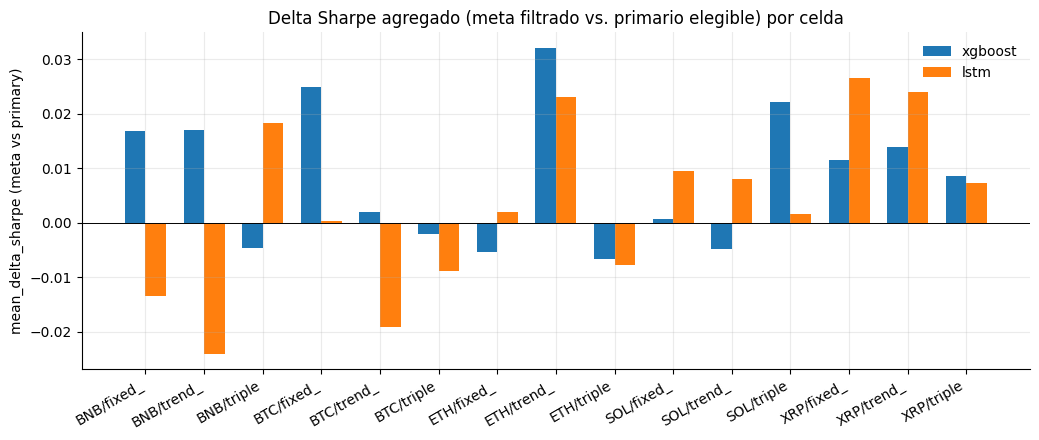

In [5]:
FAMILY_COLORS = {"xgboost": "#1f77b4", "lstm": "#ff7f0e"}

_METHOD_SHORT: dict[str, str] = {
    "triple_barrier": "trip_bar",
    "trend_scanning": "trend",
    "fixed_horizon": "fixed_h",
}


def _cell_label(symbol: str, method: str) -> str:
    short = _METHOD_SHORT.get(method, method.replace("_", "")[:8])
    return f"{symbol[:3]}/{short}"


if not completed_df.empty:
    df = completed_df.copy()
    df["cell"] = df.apply(
        lambda r: _cell_label(str(r["symbol"]), str(r["method"])), axis=1
    )
    cells = sorted(df["cell"].unique())
    x = np.arange(len(cells))
    width = 0.35
    fig, ax = plt.subplots(figsize=(max(8, len(cells) * 0.7), 4.5))
    for offset, family in zip((-width / 2, width / 2), ("xgboost", "lstm")):
        sub = df[df["primary_family"] == family].set_index("cell")
        heights = [
            float(sub.loc[c, "mean_delta_sharpe"]) if c in sub.index else np.nan
            for c in cells
        ]
        ax.bar(x + offset, heights, width=width, label=family, color=FAMILY_COLORS[family])
    ax.set_xticks(x)
    ax.set_xticklabels(cells, rotation=30, ha="right")
    ax.axhline(0, color="black", linewidth=0.7)
    ax.set_ylabel("mean_delta_sharpe (meta vs primary)")
    ax.set_title(
        "Delta Sharpe agregado (meta filtrado vs. primario elegible) por celda"
    )
    ax.legend(loc="best", frameon=False)
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / f"delta_sharpe__{CANONICAL_RUN_KEY}.png", dpi=160)
    plt.show()
else:
    print("No hay estudios meta `completed` para graficar.")

## 4. Sharpe primario vs meta filtrado (dispersión)

Cada punto es un estudio meta `completed`. El eje X es el Sharpe del primario sobre filas elegibles y el eje Y el del flujo tras el meta-filtro. Los puntos por encima de la diagonal `y = x` indican que el meta-filtro mejora el Sharpe; por debajo, lo empeora. Colores: `xgboost` (azul) y `lstm` (naranja).

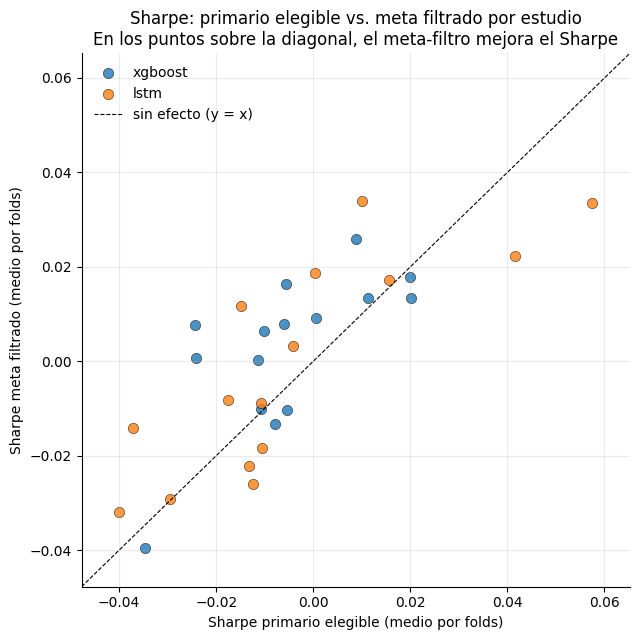

In [6]:
if not completed_df.empty:
    fig, ax = plt.subplots(figsize=(6.5, 6.5))
    for family in ("xgboost", "lstm"):
        sub = completed_df[completed_df["primary_family"] == family]
        ax.scatter(
            sub["mean_primary_eligible_sharpe"],
            sub["mean_meta_filtered_sharpe"],
            label=family,
            color=FAMILY_COLORS[family],
            alpha=0.8,
            edgecolor="black",
            linewidth=0.4,
            s=55,
        )
    serie = pd.concat([
        completed_df["mean_primary_eligible_sharpe"],
        completed_df["mean_meta_filtered_sharpe"],
    ]).dropna()
    lo, hi = float(serie.min()), float(serie.max())
    pad = (hi - lo) * 0.08 or 0.01
    lims = [lo - pad, hi + pad]
    ax.plot(lims, lims, color="black", linewidth=0.8, linestyle="--",
            label="sin efecto (y = x)")
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_xlabel("Sharpe primario elegible (medio por folds)")
    ax.set_ylabel("Sharpe meta filtrado (medio por folds)")
    ax.set_title(
        "Sharpe: primario elegible vs. meta filtrado por estudio\n"
        "En los puntos sobre la diagonal, el meta-filtro mejora el Sharpe"
    )
    ax.legend(loc="best", frameon=False)
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / f"sharpe_primary_vs_meta__{CANONICAL_RUN_KEY}.png", dpi=160)
    plt.show()
else:
    print("No hay estudios meta `completed` para graficar.")

## 5. Distribución de métricas del meta-modelo por familia

Diagramas de caja de las métricas agregadas por familia primaria (`xgboost` vs `lstm`) sobre los estudios `completed`: `meta_f1`, ratio de cobertura, ratio de filtrado y delta de Sharpe. Resume la dispersión entre celdas del panel, no solo el promedio.

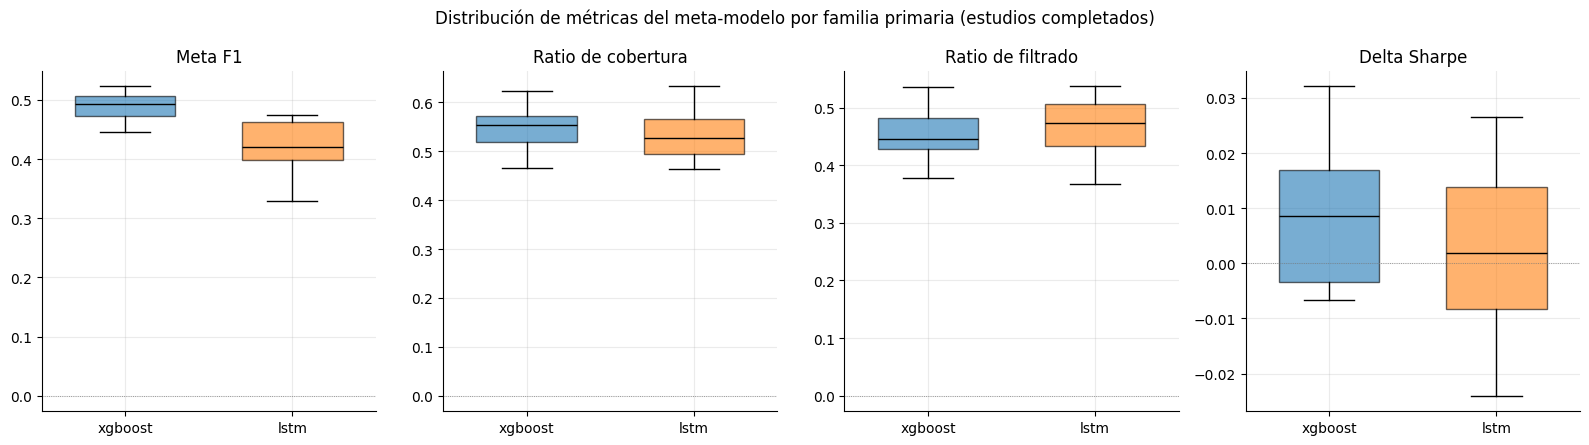

In [7]:
if not completed_df.empty:
    metricas = [
        ("mean_meta_f1", "Meta F1"),
        ("mean_coverage_ratio", "Ratio de cobertura"),
        ("mean_filter_ratio", "Ratio de filtrado"),
        ("mean_delta_sharpe", "Delta Sharpe"),
    ]
    familias = ["xgboost", "lstm"]
    fig, axes = plt.subplots(1, len(metricas), figsize=(4 * len(metricas), 4.5))
    for ax, (col, etiqueta) in zip(axes, metricas):
        datos = [
            completed_df.loc[completed_df["primary_family"] == fam, col].dropna().values
            for fam in familias
        ]
        bp = ax.boxplot(datos, tick_labels=familias, patch_artist=True, widths=0.6)
        for caja, fam in zip(bp["boxes"], familias):
            caja.set_facecolor(FAMILY_COLORS[fam])
            caja.set_alpha(0.6)
        for mediana in bp["medians"]:
            mediana.set_color("black")
        ax.set_title(etiqueta)
        ax.axhline(0, color="grey", linewidth=0.6, linestyle=":")
    fig.suptitle(
        "Distribución de métricas del meta-modelo por familia primaria "
        "(estudios completados)"
    )
    fig.tight_layout()
    fig.savefig(
        FIGURE_DIR / f"meta_metric_distributions_by_family__{CANONICAL_RUN_KEY}.png",
        dpi=160,
    )
    plt.show()
else:
    print("No hay estudios meta `completed` para graficar.")

## 6. Conclusiones finales

**Cobertura.** La corrida exploratoria `disabled_gate_best_per_family_with_fallback` cubre el panel completo 5×3 (15 celdas) con un meta-estudio por familia primaria (`xgboost` y `lstm`), de modo que los 30 candidatos resultan `completed` y ninguno queda `not_executable`.

**Efecto del meta-filtro.** El delta de Sharpe entre el primario elegible y el flujo tras el meta-filtro es **ligeramente positivo de media, pero heterogéneo y de magnitud reducida**: por familia, la media de `mean_delta_sharpe` es 0.0031 en `lstm` y 0.0084 en `xgboost`, con medianas 0.0020 y 0.0086 respectivamente. En la dispersión los puntos se reparten cerca de la diagonal `y = x` y, por celda, el signo de `mean_delta_sharpe` alterna entre familias y métodos. La lectura prudente es que el meta-labeling aporta un filtrado verificable y ocasionalmente favorable, pero no una mejora fuerte ni robusta del primario.

**Comportamiento por familia.** Las distribuciones por familia (`meta_f1`, ratio de cobertura, ratio de filtrado, delta de Sharpe) muestran rangos solapados entre `xgboost` y `lstm`: `xgboost` presenta mayor `meta_f1` medio (0.4907 frente a 0.4241), pero los ratios de cobertura y filtrado son parecidos y ninguna familia domina de forma clara en el efecto económico del meta-modelo.

**Interpretación.** La evidencia respalda presentar el meta-labeling como **capa de filtrado de ejecución implementada y verificable**, no como fuente de mejora garantizada de rendimiento. El valor metodológico está en el pipeline reproducible (OOF anti-leakage, comparación primario vs filtrado por *fold*) y en la trazabilidad del efecto marginal, más que en una ganancia estadística fuerte.

### Productos exportados

Raíz: `reports/validation/experiments/meta_labeling_shortlist_evidence/`

**Tablas** (`tables/`):

- `panel_coverage_by_definitive_run.csv` / `.md`
- `completed_meta_studies.csv`
- `completed_meta_studies_aggregate_by_family.csv`
- `definitive_runs_manifest.csv` / `.md`

**Figuras** (`figures/`, corrida `disabled_gate_best_per_family_with_fallback`):

- `delta_sharpe__disabled_gate_best_per_family_with_fallback.png`
- `sharpe_primary_vs_meta__disabled_gate_best_per_family_with_fallback.png`
- `meta_metric_distributions_by_family__disabled_gate_best_per_family_with_fallback.png`

**Entrada externa (solo lectura):** JSON por celda en `reports/validation/experiments/advanced_studies/meta_labeling_shortlist_*.json`; log de lote `logs/meta_labeling_exp15_batch_best_per_family_disabled_fallback_20260504_131934.log`.

### Notebooks relacionados

- `05_modelado_predictivo/04_evidencia_robustez_fold_shortlist_meta_labeling.ipynb`: complemento fold-level (mismo manifest `meta_labeling_shortlist_evidence/`; figuras bajo `figures/fold_meta_robustness/`).

In [8]:
lower, upper = CANONICAL_RUN.generated_at_window_utc
manifest_df = pd.DataFrame([{
    "key": CANONICAL_RUN.key,
    "label": CANONICAL_RUN.label,
    "meta_gate_mode": CANONICAL_RUN.meta_gate_mode,
    "shortlist_selection": CANONICAL_RUN.shortlist_selection,
    "expected_meta_gate_eps": CANONICAL_RUN.expected_meta_gate_eps,
    "requires_ranking_source": CANONICAL_RUN.requires_ranking_source,
    "generated_at_lower_utc": lower,
    "generated_at_upper_utc": upper,
    "batch_log_filename": CANONICAL_RUN.batch_log_filename,
}])
manifest_df.to_csv(TABLE_DIR / "definitive_runs_manifest.csv", index=False)
manifest_df.to_markdown(TABLE_DIR / "definitive_runs_manifest.md", index=False)
display_es(manifest_df)

,clave,etiqueta,modo_meta_gate,seleccion_shortlist,eps_meta_gate_esperado,requiere_fuente_ranking,generado_desde_utc,generado_hasta_utc,fichero_log_lote
0,disabled_gate_best_per_family_with_fallback,Disabled gate sobre best_per_family con fallback confirmatorio -> exploratorio por familia,disabled,best_per_family,0.0000,True,2026-05-04T11:00:00+00:00,2026-05-29T00:00:00+00:00,meta_labeling_exp15_batch_best_per_family_disabled_fallback_20260504_131934.log
